In [27]:
from processor.processor import Processor as processor
from extractor.alp_client_extractor import ALPClientExtractor
from database.adatabase import ADatabase
from xgboost import XGBRegressor
from statistics import mean
import math
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm
from dotenv import load_dotenv
load_dotenv()
import os
import warnings
warnings.simplefilter(action="ignore")

In [46]:
key = os.getenv("APCAKEY")
secret = os.getenv("APCASECRET")
alp_client = ALPClientExtractor(key,secret)
account = alp_client.account()
cash = float(account["cash"])
factors =  ["AMZN","GOOGL","AAPL","NVDA","TSLA","MSFT","META"]
market = ADatabase("market")
holding_period = 5
stoploss = 1
positions = 1
sec = ADatabase("sec")

In [29]:
def calculate_expected_return(row, factors):
    factor_loadings = [row[factor] * row[f"{factor}_beta"] for factor in factors]
    return np.mean(factor_loadings)

In [30]:
sp500 = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",attrs={"id":"constituents"})[0].rename(columns={"Symbol":"ticker"})
sp500

,ticker,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [31]:
## download factors
factor_dfs = []
market.connect()
for ticker in factors:
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","ticker","adjclose"]]
        ticker_prices["historical_return"] = ticker_prices["adjclose"].pct_change(holding_period) 
        factor_dfs.append(ticker_prices)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()
factor_df = pd.concat(factor_dfs).pivot_table(index="date",columns="ticker",values="historical_return").reset_index()
factor_df

ticker,date,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
0,2022-03-29 04:00:00+00:00,0.060064,0.026866,0.018875,0.060974,0.037328,0.080380,0.106208
1,2022-03-30 04:00:00+00:00,0.044416,0.017686,0.026468,0.067413,0.047982,0.080206,0.094944
2,2022-03-31 04:00:00+00:00,0.003102,-0.003972,-0.017659,0.012707,0.013844,-0.030693,0.062816
3,2022-04-01 04:00:00+00:00,-0.002347,-0.007344,-0.010729,0.013660,0.018901,-0.035389,0.073171
4,2022-04-04 04:00:00+00:00,0.016173,-0.003787,0.010674,0.046066,0.013743,-0.030440,0.049100
...,...,...,...,...,...,...,...,...
492,2024-03-14 04:00:00+00:00,0.023669,0.010915,0.064891,-0.039751,0.039302,-0.050988,-0.090400
493,2024-03-15 04:00:00+00:00,0.011070,-0.005304,0.042611,-0.043186,0.025110,0.003525,-0.067127
494,2024-03-18 04:00:00+00:00,0.005615,0.014655,0.072710,0.027689,0.031642,0.031257,-0.022332
495,2024-03-19 04:00:00+00:00,0.016452,0.002908,0.061588,-0.007024,0.014761,-0.027363,-0.035034


In [32]:
simulation = []
market.connect()
for ticker in tqdm(sp500["ticker"]):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices["ticker"] = ticker
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices = processor.merge(ticker_prices,factor_df.copy(),on="date")
        ticker_prices["historical_return"] = ticker_prices["adjclose"].pct_change(holding_period)
        for factor in factors:
            ticker_prices[f"{factor}_covariance"] = ticker_prices["historical_return"].rolling(100).cov(ticker_prices[factor])
            ticker_prices[f"{factor}_beta"] = ticker_prices[f"{factor}_covariance"] / ticker_prices[factor].rolling(100).var()
            ticker_prices[f"{factor}_loading"] = ticker_prices[factor] * ticker_prices[f"{factor}_beta"]
        ticker_prices["average_return"] = ticker_prices["adjclose"].pct_change(holding_period).rolling(100).mean()
        ticker_prices["coev"] = ticker_prices["adjclose"].rolling(100).std() / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["rr"] = ticker_prices["adjclose"].pct_change(5).rolling(100).mean() / ticker_prices["coev"]
        ticker_prices.dropna(inplace=True)
        ticker_prices["buy_date"] = ticker_prices["date"].shift(-1)
        ticker_prices["sell_date"] = ticker_prices["date"].shift(-holding_period)
        ticker_prices["buy_price"] = ticker_prices["adjclose"].shift(-1)
        ticker_prices["sell_price"] = ticker_prices["adjclose"].shift(-holding_period)
        ticker_prices["return"] = (ticker_prices["sell_price"] - ticker_prices["buy_price"]) / ticker_prices["buy_price"]
        ticker_prices["expected_return"] = ticker_prices.apply(lambda row: calculate_expected_return(row, factors), axis=1)
        simulation.append(ticker_prices)
    except Exception as e:
        print(ticker,str(e))
        continue
sim = pd.concat(simulation)

 29%|█████████████████████████████████████▊                                                                                             | 145/503 [00:05<00:12, 28.15it/s]

DECK 'date'


 46%|████████████████████████████████████████████████████████████▋                                                                      | 233/503 [00:09<00:10, 26.53it/s]

DOC 'date'


 86%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                  | 432/503 [00:16<00:02, 28.27it/s]

SMCI 'date'


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [00:19<00:00, 25.58it/s]


In [33]:
sim

,date,adjclose,ticker,year,quarter,month,week,weekday,AAPL,AMZN,...,META_loading,average_return,coev,rr,buy_date,sell_date,buy_price,sell_price,return,expected_return
104,2022-08-19 04:00:00+00:00,145.20,MMM,2022,3,8,33,4,-0.003370,-0.037060,...,-0.014093,0.000181,0.056597,0.003190,2022-08-22 04:00:00+00:00,2022-08-26 04:00:00+00:00,141.59,129.14,-0.087930,-0.007679
105,2022-08-22 04:00:00+00:00,141.59,MMM,2022,3,8,34,0,-0.032450,-0.069563,...,-0.020705,-0.000612,0.056261,-0.010877,2022-08-23 04:00:00+00:00,2022-08-29 04:00:00+00:00,141.75,126.44,-0.108007,-0.018156
106,2022-08-23 04:00:00+00:00,141.75,MMM,2022,3,8,34,1,-0.033520,-0.077082,...,-0.021920,-0.001432,0.055961,-0.025593,2022-08-24 04:00:00+00:00,2022-08-30 04:00:00+00:00,141.04,124.86,-0.114719,-0.017639
107,2022-08-24 04:00:00+00:00,141.04,MMM,2022,3,8,34,2,-0.040218,-0.058410,...,-0.014398,-0.001859,0.055824,-0.033300,2022-08-25 04:00:00+00:00,2022-08-31 04:00:00+00:00,142.76,124.35,-0.128958,-0.014568
108,2022-08-25 04:00:00+00:00,142.76,MMM,2022,3,8,34,3,-0.023658,-0.035278,...,-0.007350,-0.002075,0.055619,-0.037308,2022-08-26 04:00:00+00:00,2022-09-01 04:00:00+00:00,129.14,125.63,-0.027180,-0.009531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,2024-03-14 04:00:00+00:00,173.88,ZTS,2024,1,3,11,3,0.023669,0.010915,...,-0.009236,0.002924,0.066109,0.044236,2024-03-15 04:00:00+00:00,NaT,172.57,NaN,NaN,0.001432
498,2024-03-15 04:00:00+00:00,172.57,ZTS,2024,1,3,11,4,0.011070,-0.005304,...,-0.010252,0.002816,0.065725,0.042845,2024-03-18 04:00:00+00:00,NaT,170.69,NaN,NaN,-0.000561
499,2024-03-18 04:00:00+00:00,170.69,ZTS,2024,1,3,12,0,0.005615,0.014655,...,0.006312,0.002614,0.065406,0.039964,2024-03-19 04:00:00+00:00,NaT,172.96,NaN,NaN,0.006271
500,2024-03-19 04:00:00+00:00,172.96,ZTS,2024,1,3,12,1,0.016452,0.002908,...,-0.001586,0.002561,0.064996,0.039402,2024-03-20 04:00:00+00:00,NaT,170.99,NaN,NaN,0.001943


In [47]:
trades = sim[sim["weekday"]==4].copy()
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades.sort_values("date",inplace=True)
iteration_trades = trades.copy().sort_values("coev",ascending=False).groupby("date").nth([i for i in range(positions)]).reset_index()
iteration_trades.sort_values("date",inplace=True)
iteration_trades

,index,date,adjclose,ticker,year,quarter,month,week,weekday,AAPL,...,META_loading,average_return,coev,rr,buy_date,sell_date,buy_price,sell_price,return,expected_return
6,104,2022-08-19 04:00:00+00:00,39.650,RCL,2022,3,8,33,4,-0.003370,...,-0.055322,-0.023700,0.342270,-0.069245,2022-08-22 04:00:00+00:00,2022-08-26 04:00:00+00:00,37.78,42.300,0.119640,-0.031217
8,109,2022-08-26 04:00:00+00:00,42.300,RCL,2022,3,8,34,4,-0.046059,...,-0.028142,-0.028428,0.336208,-0.084554,2022-08-29 04:00:00+00:00,2022-09-02 04:00:00+00:00,42.19,41.000,-0.028206,-0.057827
10,114,2022-09-02 04:00:00+00:00,41.000,RCL,2022,3,9,35,4,-0.047733,...,-0.006878,-0.026201,0.326907,-0.080148,2022-09-06 04:00:00+00:00,2022-09-12 04:00:00+00:00,41.83,48.040,0.148458,-0.051690
13,118,2022-09-09 04:00:00+00:00,47.240,RCL,2022,3,9,36,4,-0.003735,...,0.018232,-0.023718,0.310573,-0.076367,2022-09-12 04:00:00+00:00,2022-09-16 04:00:00+00:00,48.04,50.440,0.049958,0.025359
21,123,2022-09-16 04:00:00+00:00,135.810,FSLR,2022,3,9,37,4,-0.042384,...,-0.063076,0.034501,0.289983,0.118975,2022-09-19 04:00:00+00:00,2022-09-23 04:00:00+00:00,137.04,129.850,-0.052466,-0.059335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,479,2024-02-16 05:00:00+00:00,173.870,AMD,2024,1,2,7,4,-0.034631,...,0.005719,0.030992,0.201618,0.153718,2024-02-20 05:00:00+00:00,2024-02-26 05:00:00+00:00,165.69,176.010,0.062285,-0.023062
77,483,2024-02-23 05:00:00+00:00,176.520,AMD,2024,1,2,8,4,-0.007288,...,0.000000,0.029773,0.199350,0.149352,2024-02-26 05:00:00+00:00,2024-03-01 05:00:00+00:00,176.01,202.640,0.151298,0.011976
73,488,2024-03-01 05:00:00+00:00,822.790,NVDA,2024,1,3,9,4,-0.015670,...,0.030481,0.030934,0.207303,0.149221,2024-03-04 05:00:00+00:00,2024-03-08 05:00:00+00:00,852.37,875.280,0.026878,0.011449
52,493,2024-03-08 05:00:00+00:00,875.280,NVDA,2024,1,3,10,4,-0.049705,...,0.005952,0.034706,0.236339,0.146847,2024-03-11 04:00:00+00:00,2024-03-15 04:00:00+00:00,857.74,878.365,0.024046,-0.004574


In [48]:
iteration_trades["return"] = iteration_trades["return"] * (1/positions)
iteration_trades["return"] = [max(float(-stoploss/positions),x) for x in iteration_trades["return"]]
portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio.iloc[:-1]
portfolio["year"] = [x.year for x in portfolio["date"]]
portfolio["return"] = portfolio["return"] + 1
portfolio["cumulative_return"] = portfolio["return"].cumprod()
portfolio

,date,return,year,cumulative_return
0,2022-08-19 04:00:00+00:00,1.119640,2022,1.119640
1,2022-08-26 04:00:00+00:00,0.971794,2022,1.088060
2,2022-09-02 04:00:00+00:00,1.148458,2022,1.249591
3,2022-09-09 04:00:00+00:00,1.049958,2022,1.312018
4,2022-09-16 04:00:00+00:00,0.947534,2022,1.243182
...,...,...,...,...
76,2024-02-09 05:00:00+00:00,1.011401,2024,2.304772
77,2024-02-16 05:00:00+00:00,1.062285,2024,2.448325
78,2024-02-23 05:00:00+00:00,1.151298,2024,2.818752
79,2024-03-01 05:00:00+00:00,1.026878,2024,2.894515


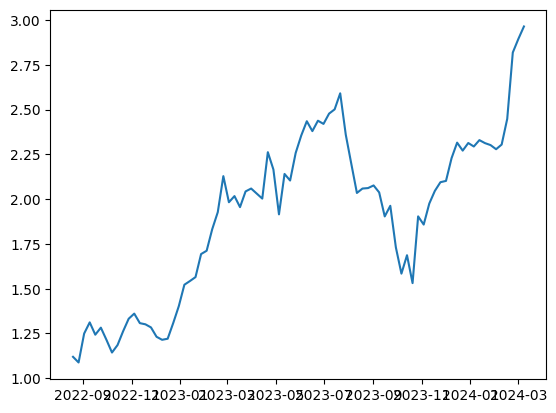

In [49]:
plt.plot(portfolio["date"].values,portfolio["cumulative_return"])

In [50]:
results = {}
results["number_of_trades"] = iteration_trades.index.size
results["standard_deviation"] = portfolio["cumulative_return"].std()
results["coefficient_of_variance"] = portfolio["cumulative_return"].std() / portfolio["cumulative_return"].mean()
results["sharpe"] = portfolio["cumulative_return"].iloc[-1] / portfolio["cumulative_return"].std()
results["return"] = portfolio["cumulative_return"].iloc[-1]
results = pd.DataFrame([results]).round(4).to_dict("records")[0]
results

{'number_of_trades': 82,
 'standard_deviation': 0.4695,
 'coefficient_of_variance': 0.2457,
 'sharpe': 6.3131,
 'return': 2.9641}